In [5]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

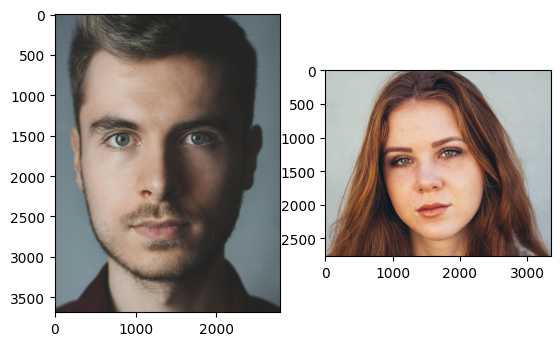

In [6]:
img_man= cv2.imread("input (2).jpg", cv2.IMREAD_COLOR)
img_man = cv2.cvtColor(img_man, cv2.COLOR_BGR2RGB)

img_woman= cv2.imread("input (1).jpg", cv2.IMREAD_COLOR)
img_woman = cv2.cvtColor(img_woman, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img_man)
plt.subplot(1,2,2)
plt.imshow(img_woman)
plt.show()

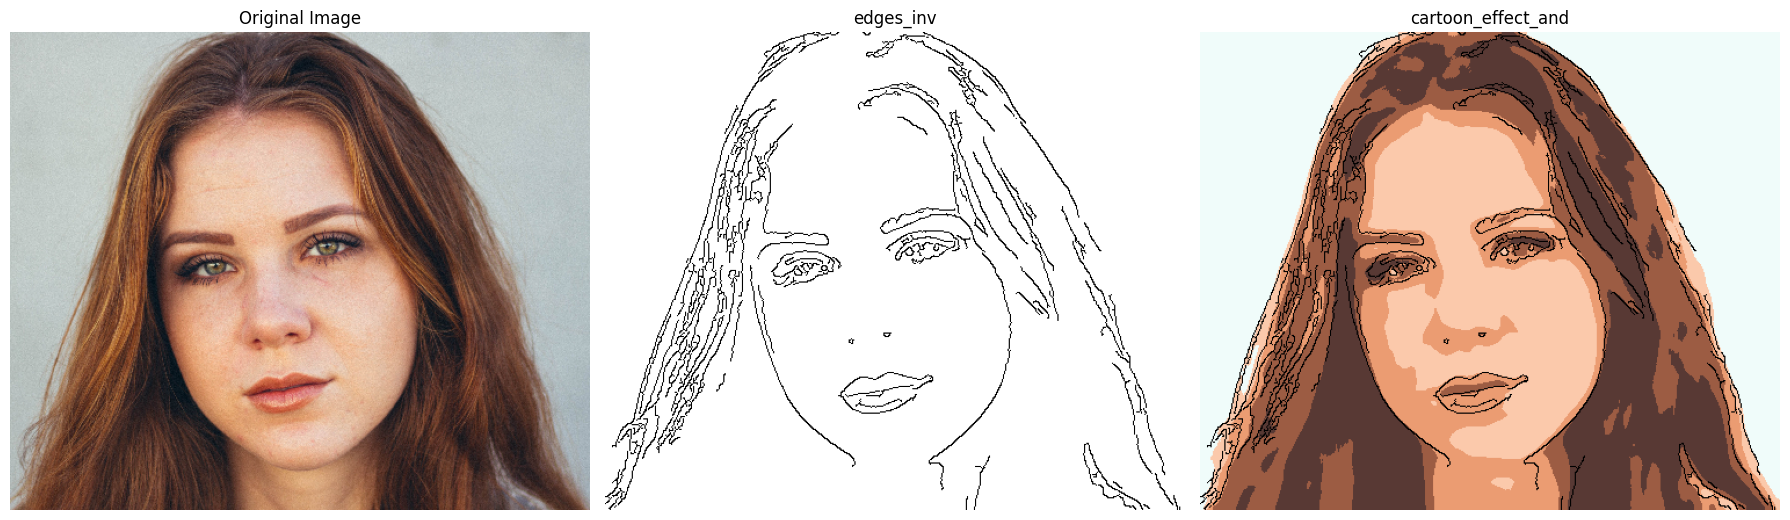

In [7]:
img = cv2.imread("input (1).jpg", cv2.IMREAD_COLOR)
if img is None:
    print("HATA: Görüntü yüklenemedi. Dosya yolu doğru mu?")
    exit()
img = cv2.resize(img, (500, int(img.shape[0] * 500 / img.shape[1])))

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
s = np.clip(cv2.multiply(s, 1.10), 0, 255).astype(np.uint8)
v = np.clip(cv2.multiply(v, 1.40), 0, 255).astype(np.uint8)
hsv_boost = cv2.merge([h, s, v])
img_boost = cv2.cvtColor(hsv_boost, cv2.COLOR_HSV2BGR)
img_base = img_boost.copy() 
gray = cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.medianBlur(gray, 5)


low_threshold = 20
high_threshold = 190
edges = cv2.Canny(gray_blurred, low_threshold, high_threshold)

kernel = np.ones((1, 1), np.uint8)
edges_dilated = cv2.dilate(edges, kernel, iterations=1)

edges_inv = cv2.bitwise_not(edges_dilated)

bilateral = cv2.bilateralFilter(img_base, 11, 300, 150)

Z = bilateral.reshape((-1, 3))
Z = np.float32(Z)
K_poster = 5 # Daha az renk, daha güçlü poster etkisi
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
ret, label, center = cv2.kmeans(Z, K_poster, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
res = center[label.flatten()]
result_color_flat = res.reshape(img_base.shape)

cartoon_effect_and = cv2.bitwise_and(result_color_flat, result_color_flat, mask=edges_inv)
cartoon_effect_not = cv2.bitwise_not(result_color_flat, result_color_flat, mask=edges_inv)

import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(18, 6))

# 1) Original
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 2) Edge Map
plt.subplot(1, 3, 2)
plt.title("edges_inv")
plt.imshow(edges_inv, cmap="gray")
plt.axis("off")

# 3) Cartoon Output
plt.subplot(1, 3, 3)
plt.title("cartoon_effect_and")
plt.imshow(cv2.cvtColor(cartoon_effect_and, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()



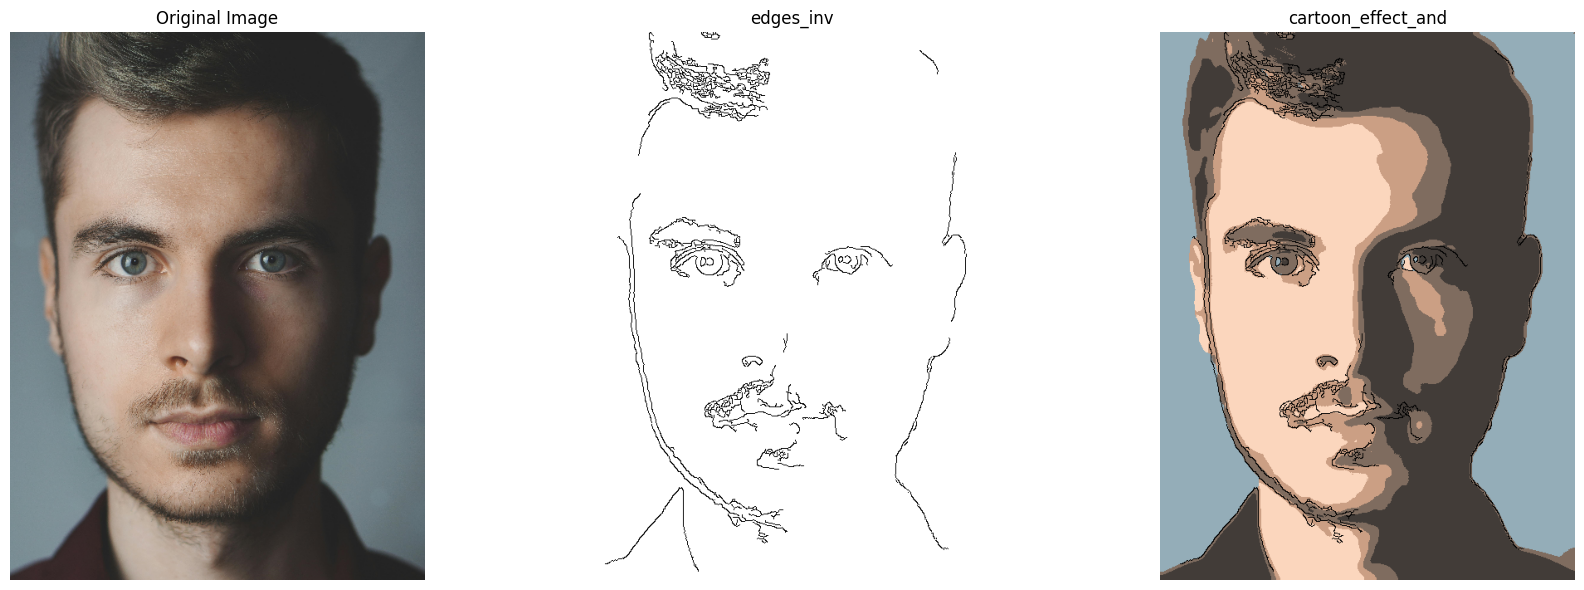

In [8]:
img = cv2.imread("input (2).jpg", cv2.IMREAD_COLOR)
if img is None:
    print("HATA: Görüntü yüklenemedi. Dosya yolu doğru mu?")
    exit()
img = cv2.resize(img, (500, int(img.shape[0] * 500 / img.shape[1])))

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
s = np.clip(cv2.multiply(s, 1.10), 0, 255).astype(np.uint8)
v = np.clip(cv2.multiply(v, 1.40), 0, 255).astype(np.uint8)
hsv_boost = cv2.merge([h, s, v])
img_boost = cv2.cvtColor(hsv_boost, cv2.COLOR_HSV2BGR)
img_base = img_boost.copy() 
gray = cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.medianBlur(gray, 5)


low_threshold = 20
high_threshold = 190
edges = cv2.Canny(gray_blurred, low_threshold, high_threshold)

kernel = np.ones((1, 1), np.uint8)
edges_dilated = cv2.dilate(edges, kernel, iterations=1)

edges_inv = cv2.bitwise_not(edges_dilated)

bilateral = cv2.bilateralFilter(img_base, 11, 300, 150)

Z = bilateral.reshape((-1, 3))
Z = np.float32(Z)
K_poster = 5 # Daha az renk, daha güçlü poster etkisi
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
ret, label, center = cv2.kmeans(Z, K_poster, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
res = center[label.flatten()]
result_color_flat = res.reshape(img_base.shape)

cartoon_effect_and = cv2.bitwise_and(result_color_flat, result_color_flat, mask=edges_inv)
cartoon_effect_not = cv2.bitwise_not(result_color_flat, result_color_flat, mask=edges_inv)

import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(18, 6))

# 1) Original
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

# 2) Edge Map
plt.subplot(1, 3, 2)
plt.title("edges_inv")
plt.imshow(edges_inv, cmap="gray")
plt.axis("off")

# 3) Cartoon Output
plt.subplot(1, 3, 3)
plt.title("cartoon_effect_and")
plt.imshow(cv2.cvtColor(cartoon_effect_and, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

